# Case 3: full remainder decomposition (saved results only)

This notebook reads **800 already-computed Adam results**, at 1,000 epochs and full sample sizes $n=500,1000,2000,4000$ (200 replications each). All root-sample-size calculations use **$N=n_{\mathrm{train}}=0.8n$**. It imports no training or DGP code, loads no networks, generates no observations, and writes no CSV or figure files. Tables and figures are embedded when the notebook is executed and saved.

Inputs: `../run_psi_n_if/replication_terms.csv`, with `../run/raw_replications.csv` used only to match keys, hashes, sample sizes, and the saved $A_N$. Definitions were read from `../psi_n_if_helpers.py`; covariance conventions follow the [previous corrected diagnostic](../corrected_asymptotic_normality_post_analysis/corrected_asymptotic_normality_post_analysis.ipynb). The conclusions below describe this stored data snapshot, not a new simulation or an asymptotic proof.

## Exact accounting and the evaluation-noise caveat

Read $A_N$, $P_{\rm fit}$, $P_{00}$, and $\widehat P_{\rm pop}$ from `adam_sn_xi_*`, `adam_sn_psi_fit_*`, `adam_sn_psi_00_*`, and `adam_sn_psi0_N_*`. Build the full symmetric $\Sigma_2$ from `adam_Sigma2_11/12/22`. Define
$$
R_{\rm EP}=P_{\rm fit}-\widehat P_{\rm pop}-P_{00},\qquad
R_{\rm Taylor}=\widehat P_{\rm pop}-\Sigma_2A_N.
$$
Then, as finite-sample identities,
$$
\begin{aligned}
\Sigma_2 A_N&=P_{\rm fit}-P_{00}-R_{\rm EP}-R_{\rm Taylor},\\
A_N&=\underbrace{\Sigma_2^{-1}P_{\rm fit}}_{\text{score}}
+\underbrace{-\Sigma_2^{-1}P_{00}}_{\text{IF}}
+\underbrace{-\Sigma_2^{-1}R_{\rm EP}}_{\text{EP}}
+\underbrace{-\Sigma_2^{-1}R_{\rm Taylor}}_{\text{Taylor}},\\
C_N&=A_N-\text{score}=\text{IF}+\text{EP}+\text{Taylor},\\
A_N-\Sigma_2^{-1}P_{\rm fit}
+\Sigma_2^{-1}R_{\rm EP}+\Sigma_2^{-1}R_{\rm Taylor}
&=\text{IF}.
\end{aligned}
$$
All inverse actions below use `np.linalg.solve`. The last quantity is an oracle accounting benchmark, not a new feasible estimator.

**Do not substitute the stored `adam_Gap_EP_*` columns:** the helper defines them as $\widehat P_{\rm pop}+P_{00}$, which differs from the $R_{\rm EP}$ requested here. Its `adam_Gap_Taylor_*` agrees with $R_{\rm Taylor}$ and is checked only as a consistency check. Its `adam_C_n_*` has a different meaning from $C_N$ here.

**Finite evaluation sample:** $\widehat P_{\rm pop}$ uses a previously generated independent sample of `n_eval=50,000`. If $\widehat P_{\rm pop}=P_{\rm pop}+e$, the coefficient-space EP term gains $\Sigma_2^{-1}e$ and the Taylor term loses exactly the same vector. Thus separate means, SDs, and their covariance contain evaluation noise; **EP + Taylor, $C_N$, and IF are invariant to it**. Conditional mean-zero evaluation noise does not systematically bias the decomposition, but affects this finite replication average. Its root-$N$ scale involves $\sqrt{N/n_{\rm eval}}$, so a fixed evaluation size can obscure shrinking intrinsic remainders. The CSV contains no evaluation-level moments to disentangle that noise. No evaluation sample is regenerated or enlarged.

In [9]:
from pathlib import Path
import hashlib
import json
import platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display

ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "dqAux.py").is_file())
EXPERIMENT = ROOT / "results" / "2026-09-11_asymptotic_normality_case3"
TERMS_PATH = EXPERIMENT / "run_psi_n_if" / "replication_terms.csv"
RAW_PATH = EXPERIMENT / "run" / "raw_replications.csv"
CONFIG_PATH = EXPERIMENT / "run" / "run_config.json"
HELPER_PATH = EXPERIMENT / "psi_n_if_helpers.py"  # Read/hash only; never import.
CONTEXT_PATH = (EXPERIMENT / "corrected_asymptotic_normality_post_analysis"
                / "corrected_asymptotic_normality_post_analysis.ipynb")
EPOCHS, NS = 1000, [500, 1000, 2000, 4000]
ATOL, RTOL = 1e-10, 1e-10
CRITICAL = float(norm.ppf(0.975))

input_hashes = {str(p.relative_to(ROOT)): hashlib.sha256(p.read_bytes()).hexdigest()
                for p in (TERMS_PATH, RAW_PATH, CONFIG_PATH, HELPER_PATH, CONTEXT_PATH)}
source = pd.read_csv(TERMS_PATH)
d = source.loc[source["epochs"].eq(EPOCHS) & source["n"].isin(NS)].copy()
d = d.sort_values(["n", "rep"]).reset_index(drop=True)
assert set(d["n"]) == set(NS)
assert not d.duplicated(["n", "epochs", "rep"]).any()
assert len(d) > 0 and d["n_eval"].eq(50_000).all()
identity = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))["identity"]
TAU = float(identity["tau"])
assert identity["case"] == 3 and TAU == 0.5
np.testing.assert_array_equal(
    d["n_train"], (d["n"] * identity["train_fraction"]).astype(int)
)
required = [f"adam_{stem}_{j}" for stem in
            ("sn_xi", "sn_psi_fit", "sn_psi_00", "sn_psi0_N") for j in (1, 2)]
required += ["adam_Sigma2_11", "adam_Sigma2_12", "adam_Sigma2_22", "oracle_f0"]
assert np.isfinite(d[required].to_numpy(dtype=float)).all()
assert (d["oracle_f0"] > 0).all()
np.testing.assert_allclose(d["oracle_f0"], 2 / (np.pi * np.sqrt(3)), rtol=1e-12)

raw = pd.read_csv(RAW_PATH)
keys = ["n", "epochs", "rep"]
matched = d[keys + ["n_train", "data_sha256"]].merge(
    raw[keys + ["n_train", "data_sha256", "root_n_train_error_1", "root_n_train_error_2"]],
    on=keys, how="left", validate="one_to_one", suffixes=("", "_raw"), indicator=True,
)
assert matched["_merge"].eq("both").all()
assert matched["data_sha256"].eq(matched["data_sha256_raw"]).all()
np.testing.assert_array_equal(matched["n_train"], matched["n_train_raw"])
np.testing.assert_allclose(
    d[["adam_sn_xi_1", "adam_sn_xi_2"]],
    matched[["root_n_train_error_1", "root_n_train_error_2"]], rtol=RTOL, atol=ATOL,
)
inventory = d.groupby(["n", "n_train", "epochs", "n_eval"], as_index=False).agg(Q=("rep", "size"))
assert inventory["Q"].ge(2).all()
display(inventory)
print(f"Selected {len(d)} of {len(source)} stored rows; no rows dropped for numerical failure.")
provenance = {
    "input_sha256": input_hashes, "python": platform.python_version(),
    "versions": {p: importlib.metadata.version(p)
                 for p in ("numpy", "pandas", "scipy", "matplotlib")},
    "arithmetic": "float64", "randomness_used_here": False,
    "tolerance": {"rtol": RTOL, "atol": ATOL},
    "scope": {"epochs": EPOCHS, "full_sample_sizes": NS, "rows": len(d)},
}

,n,n_train,epochs,n_eval,Q
0,500,400,1000,50000,200
1,1000,800,1000,50000,200
2,2000,1600,1000,50000,200
3,4000,3200,1000,50000,200


Selected 800 of 800 stored rows; no rows dropped for numerical failure.


In [10]:
def pair(stem):
    return d[[f"adam_{stem}_{j}" for j in (1, 2)]].to_numpy(dtype=float)

A = pair("sn_xi")
P_fit, P_00, P_pop = pair("sn_psi_fit"), pair("sn_psi_00"), pair("sn_psi0_N")
Sigma2 = np.zeros((len(d), 2, 2), dtype=float)
Sigma2[:, 0, 0] = d["adam_Sigma2_11"]
Sigma2[:, 0, 1] = Sigma2[:, 1, 0] = d["adam_Sigma2_12"]
Sigma2[:, 1, 1] = d["adam_Sigma2_22"]
eigenvalues = np.linalg.eigvalsh(Sigma2)
assert (eigenvalues[:, 0] > 0).all()
condition = eigenvalues[:, 1] / eigenvalues[:, 0]
assert (condition < 1 / np.finfo(float).eps).all()

def solve(v):
    # Explicit final axis works for batched right-hand sides in NumPy 1.x and 2.x.
    return np.linalg.solve(Sigma2, v[..., None])[..., 0]

Sigma2_A = np.einsum("rij,rj->ri", Sigma2, A)
R_EP = P_fit - P_pop - P_00
R_Taylor = P_pop - Sigma2_A
score_term = solve(P_fit)
IF_term = -solve(P_00)
EP_term = -solve(R_EP)
Taylor_term = -solve(R_Taylor)
corrected_C = A - score_term
fully_remainder_removed = A - solve(P_fit) + solve(R_EP) + solve(R_Taylor)

checks = []
def check(name, left, right):
    np.testing.assert_allclose(left, right, rtol=RTOL, atol=ATOL)
    checks.append({"identity": name, "max_abs_error": float(np.max(np.abs(left - right)))})

check("Sigma2 A = P_fit - P_00 - R_EP - R_Taylor",
      Sigma2_A, P_fit - P_00 - R_EP - R_Taylor)
check("A = score + IF + EP + Taylor", A, score_term + IF_term + EP_term + Taylor_term)
check("C = IF + EP + Taylor", corrected_C, IF_term + EP_term + Taylor_term)
check("Fully remainder removed = -solve(Sigma2, P_00)",
      fully_remainder_removed, IF_term)
check("EP + Taylor is independent of P_pop",
      EP_term + Taylor_term, solve(Sigma2_A - P_fit + P_00))
check("Reconstructed Sigma2 A matches stored values", Sigma2_A, pair("sigma2_sn_xi"))
check("Reconstructed Taylor agrees with helper", R_Taylor, pair("Gap_Taylor"))

terms = {
    "A_N": A, "score_term": score_term, "corrected_C": corrected_C,
    "IF_term": IF_term, "EP_term": EP_term, "Taylor_term": Taylor_term,
    "fully_remainder_removed": fully_remainder_removed,
}
assert all(np.isfinite(value).all() for value in terms.values())
long = pd.concat([
    d[["n", "n_train", "epochs", "rep", "n_eval"]].assign(
        coefficient=j + 1, **{name: values[:, j] for name, values in terms.items()}
    ) for j in range(2)
], ignore_index=True).sort_values(["n", "coefficient", "rep"])
print(f"All {len(d)} replications passed. Largest Sigma2 condition number: {condition.max():.4f}")
display(pd.DataFrame(checks).style.format({"max_abs_error": "{:.3e}"}))

All 800 replications passed. Largest Sigma2 condition number: 1.5650


,identity,max_abs_error
0,Sigma2 A = P_fit - P_00 - R_EP - R_Taylor,1.110e-16
1,A = score + IF + EP + Taylor,3.553e-15
2,C = IF + EP + Taylor,3.553e-15
3,"Fully remainder removed = -solve(Sigma2, P_00)",5.329e-15
4,EP + Taylor is independent of P_pop,3.553e-15
5,Reconstructed Sigma2 A matches stored values,1.332e-15
6,Reconstructed Taylor agrees with helper,1.332e-15


## Means, dispersion, and exact mean accounting

SDs use $Q-1$; the Monte Carlo SE of a mean is $\mathrm{SD}/\sqrt Q$. RMSE means $\sqrt{Q^{-1}\sum_q T_q^2}$, measuring size relative to zero, and `mean_abs` is $Q^{-1}\sum_q|T_q|$. Small signed means can hide large remainders, so all seven terms have both magnitude and dispersion summaries.

The compact mean table verifies the requested sum. The score correction's signed change is $\overline A-\overline C=\overline{\mathrm{score}}$. The percentage reduction in absolute mean bias is descriptive and unstable when the original mean is near zero.

In [11]:
def mcse(x):
    return x.std(ddof=1) / np.sqrt(len(x))

tidy = long.melt(id_vars=["n", "n_train", "epochs", "rep", "coefficient"],
                 value_vars=list(terms), var_name="term", value_name="value")
full_summary = tidy.groupby(
    ["epochs", "n", "n_train", "coefficient", "term"], as_index=False, sort=False
).agg(
    Q=("value", "size"), mean=("value", "mean"), mcse=("value", mcse),
    sd=("value", "std"), rmse=("value", lambda x: np.sqrt(np.mean(np.square(x)))),
    mean_abs=("value", lambda x: np.mean(np.abs(x))),
)
full_summary["term"] = pd.Categorical(full_summary["term"], categories=list(terms), ordered=True)
full_summary = full_summary.sort_values(["n", "coefficient", "term"]).reset_index(drop=True)
means = long.groupby(["n", "n_train", "coefficient"], as_index=False)[list(terms)].mean()
mean_accounting = means[["n", "n_train", "coefficient", "corrected_C",
                         "IF_term", "EP_term", "Taylor_term"]].copy()
mean_accounting["sum_IF_EP_Taylor"] = mean_accounting[
    ["IF_term", "EP_term", "Taylor_term"]
].sum(axis=1)
mean_accounting["sum_error"] = (mean_accounting["corrected_C"]
                                 - mean_accounting["sum_IF_EP_Taylor"])
np.testing.assert_allclose(mean_accounting["sum_error"], 0, atol=ATOL, rtol=0)
bias_reduction = means[["n", "coefficient", "A_N", "score_term", "corrected_C"]].copy()
bias_reduction["abs_mean_bias_reduction_pct"] = (
    100 * (1 - bias_reduction["corrected_C"].abs()
           / bias_reduction["A_N"].abs().where(bias_reduction["A_N"].abs() > ATOL))
)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(mean_accounting.round(6))
    display(bias_reduction.round(4))
    display(full_summary.drop(columns="epochs").round(4))

,n,n_train,coefficient,corrected_C,IF_term,EP_term,Taylor_term,sum_IF_EP_Taylor,sum_error
0,500,400,1,-3.015535,0.044647,-1.709445,-1.350738,-3.015535,-0.0
1,500,400,2,3.073532,0.072360,1.492594,1.508578,3.073532,0.0
2,1000,800,1,-0.953561,-0.121770,-0.269928,-0.561863,-0.953561,0.0
3,1000,800,2,2.065754,-0.184222,1.269362,0.980614,2.065754,0.0
4,2000,1600,1,-0.151770,0.377957,-0.362384,-0.167342,-0.151770,-0.0
5,2000,1600,2,0.716586,-0.130259,0.592082,0.254763,0.716586,-0.0
6,4000,3200,1,-0.585514,-0.020207,-0.336548,-0.228759,-0.585514,-0.0
7,4000,3200,2,-0.076192,-0.264121,0.330944,-0.143015,-0.076192,0.0


,n,coefficient,A_N,score_term,corrected_C,abs_mean_bias_reduction_pct
0,500,1,-3.0264,-0.0109,-3.0155,0.3606
1,500,2,3.6582,0.5847,3.0735,15.9822
2,1000,1,-1.3937,-0.4401,-0.9536,31.5789
3,1000,2,2.3759,0.3102,2.0658,13.0549
4,2000,1,-0.5006,-0.3488,-0.1518,69.6796
5,2000,2,0.7612,0.0446,0.7166,5.8586
6,4000,1,-0.8590,-0.2735,-0.5855,31.8398
7,4000,2,-0.2406,-0.1644,-0.0762,68.3337


,n,n_train,coefficient,term,Q,mean,mcse,sd,rmse,mean_abs
0,500,400,1,A_N,200,-3.0264,0.3361,4.7530,5.6247,4.4473
1,500,400,1,score_term,200,-0.0109,0.2214,3.1317,3.1239,2.5152
2,500,400,1,corrected_C,200,-3.0155,0.3852,5.4470,6.2141,4.8766
3,500,400,1,IF_term,200,0.0446,0.2400,3.3935,3.3853,2.7303
4,500,400,1,EP_term,200,-1.7094,0.2922,4.1326,4.4626,3.6019
5,500,400,1,Taylor_term,200,-1.3507,0.1465,2.0716,2.4687,1.9343
6,500,400,1,fully_remainder_removed,200,0.0446,0.2400,3.3935,3.3853,2.7303
7,500,400,2,A_N,200,3.6582,0.3080,4.3551,5.6793,4.5781
8,500,400,2,score_term,200,0.5847,0.2014,2.8483,2.9007,2.3419
9,500,400,2,corrected_C,200,3.0735,0.3451,4.8811,5.7578,4.5315


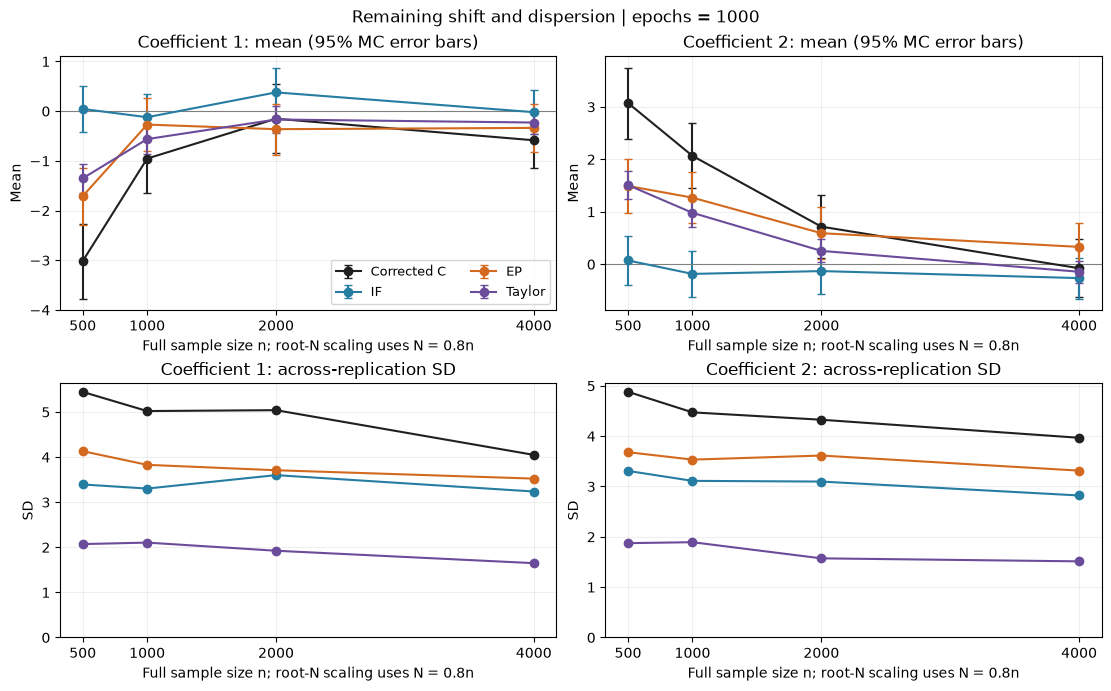

In [12]:
plot_terms = ["corrected_C", "IF_term", "EP_term", "Taylor_term"]
colors = {"corrected_C": "#202020", "IF_term": "#277DA1",
          "EP_term": "#D2691E", "Taylor_term": "#6B4C9A"}
labels = {"corrected_C": "Corrected C", "IF_term": "IF",
          "EP_term": "EP", "Taylor_term": "Taylor"}
fig, axes = plt.subplots(2, 2, figsize=(11, 6.8), constrained_layout=True)
for j in (1, 2):
    for term in plot_terms:
        g = full_summary.loc[
            full_summary["coefficient"].eq(j) & full_summary["term"].eq(term)
        ].sort_values("n")
        axes[0, j-1].errorbar(
            g["n"], g["mean"], yerr=CRITICAL*g["mcse"], marker="o",
            capsize=3, color=colors[term], label=labels[term],
        )
        axes[1, j-1].plot(g["n"], g["sd"], marker="o", color=colors[term], label=labels[term])
    axes[0, j-1].axhline(0, color="gray", linewidth=0.8)
    axes[0, j-1].set(title=f"Coefficient {j}: mean (95% MC error bars)", ylabel="Mean")
    axes[1, j-1].set(title=f"Coefficient {j}: across-replication SD", ylabel="SD", ylim=(0, None))
    for ax in axes[:, j-1]:
        ax.set_xlabel("Full sample size n; root-N scaling uses N = 0.8n")
        ax.set_xticks(NS)
        ax.grid(alpha=0.2)
axes[0, 0].legend(ncol=2, fontsize=9)
fig.suptitle("Remaining shift and dispersion | epochs = 1000")
display(fig)
plt.close(fig)

## Variance attribution must retain covariance

Writing $I=\mathrm{IF}$, $E=\mathrm{EP}$, and $T=\mathrm{Taylor}$, the sample variance identity is
$$
\operatorname{Var}(C)=\operatorname{Var}(I)+\operatorname{Var}(E)+\operatorname{Var}(T)
+2\operatorname{Cov}(I,E)+2\operatorname{Cov}(I,T)+2\operatorname{Cov}(E,T).
$$
The next table reports every term, the excess over the empirical IF variance, and the net remainder SD. For an additional arithmetic check of attribution, `var_without_EP` is $\operatorname{Var}(I+T)$ and `var_without_Taylor` is $\operatorname{Var}(I+E)$. These are decompositions of the same stored observations, not refits or causal effects. Their reductions need not add up, and removing a component can increase variance when it was cancelling another component.

The EP/Taylor split is evaluation-noise sensitive; the combined remainder and corrected variance are not. Correlations with $C$ are descriptive associations involving parts of a sum.

In [13]:
variance_rows = []
for (n, N, j), g in long.groupby(["n", "n_train", "coefficient"], sort=True):
    I, E, T, C = (g[name].to_numpy() for name in
                  ("IF_term", "EP_term", "Taylor_term", "corrected_C"))
    covariance = np.cov(np.column_stack((I, E, T)), rowvar=False, ddof=1)
    var_C, var_IF = C.var(ddof=1), covariance[0, 0]
    reconstructed = covariance.sum()
    np.testing.assert_allclose(var_C, reconstructed, rtol=RTOL, atol=ATOL)
    variance_rows.append({
        "n": n, "coefficient": j, "var_C": var_C, "var_IF": var_IF,
        "var_EP": covariance[1, 1], "var_Taylor": covariance[2, 2],
        "twice_cov_IF_EP": 2*covariance[0, 1],
        "twice_cov_IF_Taylor": 2*covariance[0, 2],
        "twice_cov_EP_Taylor": 2*covariance[1, 2],
        "variance_sum_error": var_C-reconstructed,
        "excess_over_IF": var_C-var_IF,
        "sd_EP_plus_Taylor": (E+T).std(ddof=1),
        "var_without_EP": (I+T).var(ddof=1),
        "var_without_Taylor": (I+E).var(ddof=1),
        "corr_C_EP": np.corrcoef(C, E)[0, 1],
        "corr_C_Taylor": np.corrcoef(C, T)[0, 1],
    })
variance_summary = pd.DataFrame(variance_rows)
with pd.option_context("display.max_columns", None):
    display(variance_summary[[
        "n", "coefficient", "var_C", "var_IF", "var_EP", "var_Taylor",
        "twice_cov_IF_EP", "twice_cov_IF_Taylor", "twice_cov_EP_Taylor",
        "excess_over_IF", "variance_sum_error",
    ]].round(4))
    display(variance_summary.loc[variance_summary["n"].eq(4000), [
        "n", "coefficient", "var_C", "var_without_EP", "var_without_Taylor",
        "sd_EP_plus_Taylor", "corr_C_EP", "corr_C_Taylor",
    ]].round(4))

,n,coefficient,var_C,var_IF,var_EP,var_Taylor,twice_cov_IF_EP,twice_cov_IF_Taylor,twice_cov_EP_Taylor,excess_over_IF,variance_sum_error
0,500,1,29.6697,11.5156,17.0780,4.2914,-12.6507,7.5988,1.8365,18.1541,-0.0
1,500,2,23.8253,10.9512,13.5533,3.5137,-11.7632,5.8352,1.7351,12.8741,0.0
2,1000,1,25.2236,10.9129,14.6638,4.4299,-12.7958,5.9301,2.0826,14.3107,0.0
3,1000,2,20.0072,9.6844,12.4881,3.5850,-11.3448,5.2782,0.3163,10.3228,-0.0
4,2000,1,25.4185,12.9688,13.7609,3.7022,-12.6793,8.1695,-0.5035,12.4497,0.0
5,2000,2,18.7171,9.5972,13.0671,2.4723,-11.2032,4.6195,0.1642,9.1199,-0.0
6,4000,1,16.4035,10.4834,12.4169,2.7188,-12.2234,6.0936,-3.0859,5.9201,0.0
7,4000,2,15.7450,7.9614,10.9922,2.2885,-7.4933,3.4600,-1.4637,7.7837,0.0


,n,coefficient,var_C,var_without_EP,var_without_Taylor,sd_EP_plus_Taylor,corr_C_EP,corr_C_Taylor
6,4000,1,16.4035,19.2959,10.6769,3.4713,0.3337,0.6323
7,4000,2,15.7450,13.7099,11.4602,3.4376,0.4951,0.5475


## Ideal IF calibration and the largest-sample distributions

Reuse the previous diagnostic's homoscedastic oracle covariance, with its **uncentered training moment and divisor $N$**:
$$
M_N=\Sigma_2/f(0),\quad
\Sigma_1=\tau(1-\tau)M_N,\quad
V_N=\Sigma_2^{-1}\Sigma_1\Sigma_2^{-1}.
$$
The stored $\Sigma_2$ and `oracle_f0` suffice; no new variance model, estimated density, or empirical rescaling is introduced. For original coefficient $j$, compare $C_j/\sqrt{V_{N,jj}}$ with $\mathrm{IF}_j/\sqrt{V_{N,jj}}$. The full sandwich retains cross-covariance; marginal standardization keeps coefficient labels interpretable.

The table checks IF centering, spread, and nominal 95% coverage at every $n$. Coverage is the fraction with absolute standardized statistic at most 1.96, not a claim that a feasible IF-only estimator was fit. The histograms and QQ plots below use $n=4000$, 1,000 epochs, all observations, fixed $N(0,1)$ references, and no fitted QQ line or empirical recentering.

,n,n_train,coefficient,Q,mean_Z_IF,mcse_Z_IF,sd_Z_IF,coverage_IF_95,mean_Z_C,sd_Z_C,coverage_C_95,mcse_IF_coverage
0,500,400,1,200,0.0115,0.0740,1.0465,0.950,-0.9308,1.6800,0.705,0.0154
1,500,400,2,200,0.0215,0.0745,1.0531,0.955,0.9784,1.5551,0.745,0.0147
2,1000,800,1,200,-0.0370,0.0722,1.0210,0.940,-0.2926,1.5547,0.745,0.0168
3,1000,800,2,200,-0.0577,0.0702,0.9927,0.950,0.6560,1.4210,0.805,0.0154
4,2000,1600,1,200,0.1153,0.0784,1.1083,0.925,-0.0503,1.5520,0.815,0.0186
5,2000,1600,2,200,-0.0432,0.0702,0.9930,0.960,0.2290,1.3875,0.825,0.0139
6,4000,3200,1,200,-0.0063,0.0705,0.9973,0.955,-0.1807,1.2495,0.885,0.0147
7,4000,3200,2,200,-0.0834,0.0638,0.9019,0.975,-0.0251,1.2699,0.890,0.0110


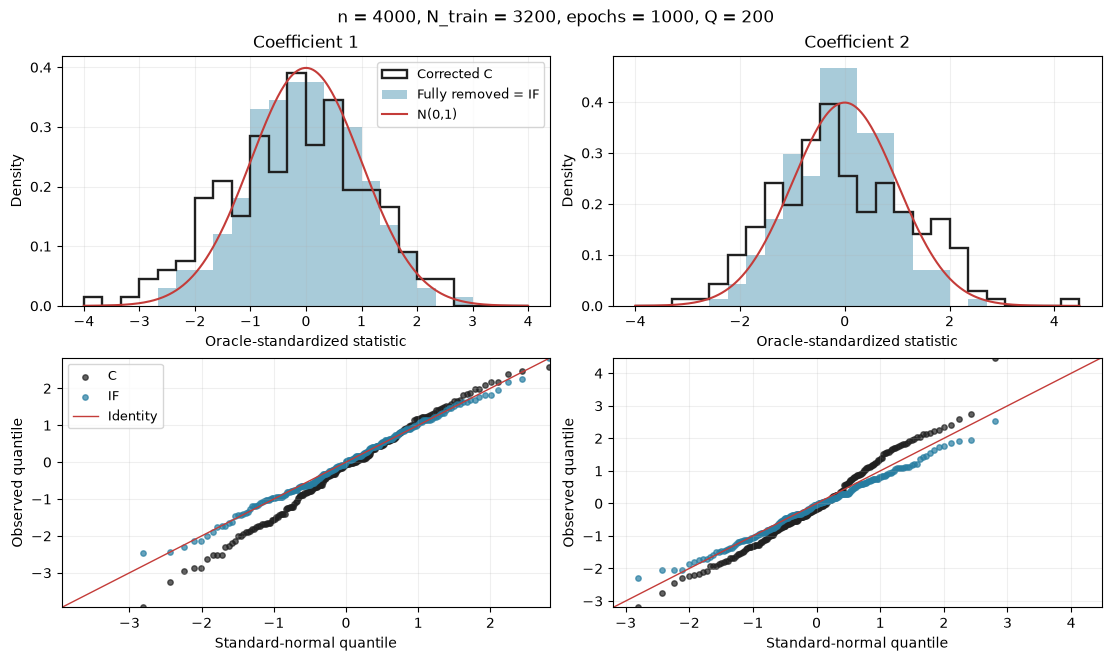

In [14]:
f0 = d["oracle_f0"].to_numpy()
Sigma1 = TAU*(1-TAU) * Sigma2 / f0[:, None, None]
left = np.linalg.solve(Sigma2, Sigma1)
V = np.linalg.solve(Sigma2, left.transpose(0, 2, 1)).transpose(0, 2, 1)
np.testing.assert_allclose(V, V.transpose(0, 2, 1), rtol=RTOL, atol=ATOL)
assert (np.linalg.eigvalsh(V) > 0).all()
sd_oracle = np.sqrt(np.diagonal(V, axis1=1, axis2=2))
standardized = pd.concat([
    d[["n", "n_train", "epochs", "rep"]].assign(
        coefficient=j+1, Z_C=corrected_C[:, j]/sd_oracle[:, j],
        Z_IF=fully_remainder_removed[:, j]/sd_oracle[:, j],
    ) for j in range(2)
], ignore_index=True)
calibration = standardized.groupby(["n", "n_train", "coefficient"], as_index=False).agg(
    Q=("rep", "size"),
    mean_Z_IF=("Z_IF", "mean"), mcse_Z_IF=("Z_IF", mcse), sd_Z_IF=("Z_IF", "std"),
    coverage_IF_95=("Z_IF", lambda x: np.mean(np.abs(x) <= CRITICAL)),
    mean_Z_C=("Z_C", "mean"), sd_Z_C=("Z_C", "std"),
    coverage_C_95=("Z_C", lambda x: np.mean(np.abs(x) <= CRITICAL)),
)
calibration["mcse_IF_coverage"] = np.sqrt(
    calibration["coverage_IF_95"]*(1-calibration["coverage_IF_95"])/calibration["Q"]
)
with pd.option_context("display.max_columns", None):
    display(calibration.round(4))

focus_standardized = standardized.loc[standardized["n"].eq(4000)]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for j in (1, 2):
    g = focus_standardized.loc[focus_standardized["coefficient"].eq(j)]
    c, ii = g["Z_C"].to_numpy(), g["Z_IF"].to_numpy()
    combined = np.concatenate((c, ii))
    lo, hi = min(-4., combined.min()), max(4., combined.max())
    bins = np.linspace(lo, hi, 25)
    ax = axes[0, j-1]
    ax.hist(c, bins=bins, density=True, histtype="step", linewidth=1.7,
            color=colors["corrected_C"], label="Corrected C")
    ax.hist(ii, bins=bins, density=True, alpha=0.4, color=colors["IF_term"],
            label="Fully removed = IF")
    grid = np.linspace(lo, hi, 400)
    ax.plot(grid, norm.pdf(grid), color="#C43C39", label="N(0,1)")
    ax.set(title=f"Coefficient {j}", xlabel="Oracle-standardized statistic", ylabel="Density")
    ax = axes[1, j-1]
    theoretical = norm.ppf((np.arange(len(g)) + .5)/len(g))
    ax.scatter(theoretical, np.sort(c), s=15, alpha=.7, color=colors["corrected_C"], label="C")
    ax.scatter(theoretical, np.sort(ii), s=15, alpha=.7, color=colors["IF_term"], label="IF")
    bounds = [min(theoretical.min(), combined.min()), max(theoretical.max(), combined.max())]
    ax.plot(bounds, bounds, color="#C43C39", linewidth=1, label="Identity")
    ax.set(xlabel="Standard-normal quantile", ylabel="Observed quantile",
           xlim=bounds, ylim=bounds)
    for ax in axes[:, j-1]:
        ax.grid(alpha=.2)
axes[0, 0].legend(fontsize=9)
axes[1, 0].legend(fontsize=9)
fig.suptitle("n = 4000, N_train = 3200, epochs = 1000, Q = 200")
display(fig)
plt.close(fig)

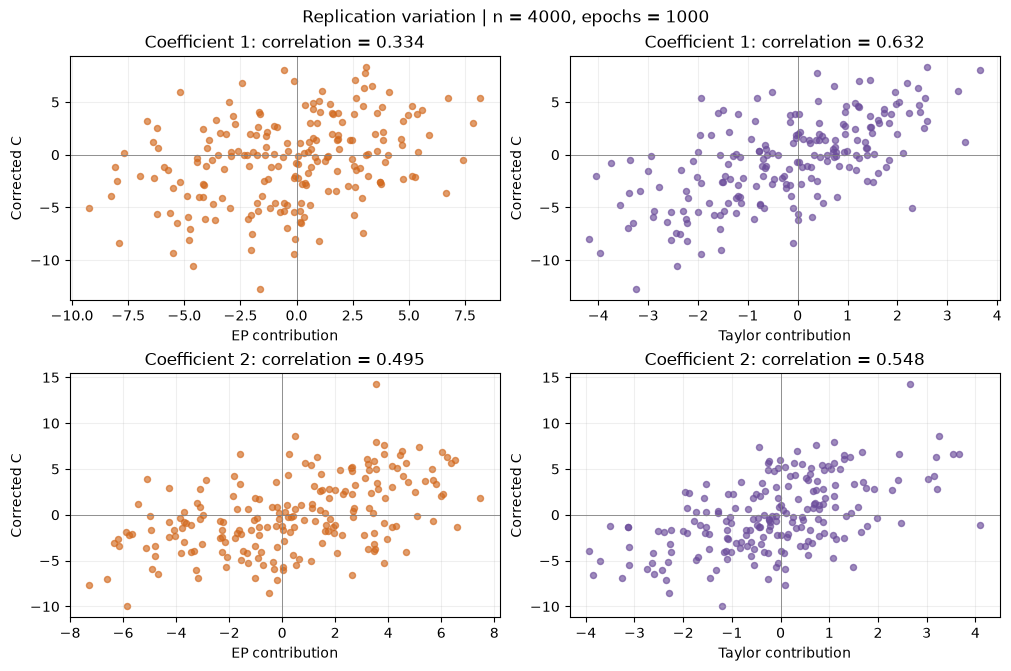

In [15]:
focus = long.loc[long["n"].eq(4000)]
fig, axes = plt.subplots(2, 2, figsize=(10, 6.6), constrained_layout=True)
for row_index, j in enumerate((1, 2)):
    g = focus.loc[focus["coefficient"].eq(j)]
    for col_index, term in enumerate(("EP_term", "Taylor_term")):
        ax = axes[row_index, col_index]
        correlation = g[["corrected_C", term]].corr().iloc[0, 1]
        ax.scatter(g[term], g["corrected_C"], s=19, alpha=.65, color=colors[term])
        ax.axhline(0, color="gray", linewidth=.6)
        ax.axvline(0, color="gray", linewidth=.6)
        ax.set(title=f"Coefficient {j}: correlation = {correlation:.3f}",
               xlabel=f"{labels[term]} contribution", ylabel="Corrected C")
        ax.grid(alpha=.2)
fig.suptitle("Replication variation | n = 4000, epochs = 1000")
display(fig)
plt.close(fig)

## Empirical size pattern and source interpretation

Compare the ordered values directly; do not fit a convergence rate to four sample sizes. Non-monotone signed means and cancellation are distinguished from decreases in SD and mean absolute size.

In [16]:
trend = full_summary.loc[
    full_summary["term"].isin(["EP_term", "Taylor_term"]),
    ["n", "coefficient", "term", "mean", "mcse", "sd", "mean_abs"],
].sort_values(["coefficient", "term", "n"])
with pd.option_context("display.max_rows", None):
    display(trend.round(4))
# Preserve the source hashes in the saved output, and check that inputs were unchanged.
assert all(hashlib.sha256((ROOT/name).read_bytes()).hexdigest() == digest
           for name, digest in input_hashes.items())
display(provenance)

,n,coefficient,term,mean,mcse,sd,mean_abs
4,500,1,EP_term,-1.7094,0.2922,4.1326,3.6019
18,1000,1,EP_term,-0.2699,0.2708,3.8293,3.1054
32,2000,1,EP_term,-0.3624,0.2623,3.7096,3.0089
46,4000,1,EP_term,-0.3365,0.2492,3.5238,2.8253
5,500,1,Taylor_term,-1.3507,0.1465,2.0716,1.9343
19,1000,1,Taylor_term,-0.5619,0.1488,2.1047,1.6973
33,2000,1,Taylor_term,-0.1673,0.1361,1.9241,1.5219
47,4000,1,Taylor_term,-0.2288,0.1166,1.6489,1.3478
11,500,2,EP_term,1.4926,0.2603,3.6815,3.1503
25,1000,2,EP_term,1.2694,0.2499,3.5339,2.9479


{'input_sha256': {'results\\2026-09-11_asymptotic_normality_case3\\run_psi_n_if\\replication_terms.csv': 'd940ef1e2cf5777723f935a81a446c8aab5fb83a5c8893861fd398a42388c762',
  'results\\2026-09-11_asymptotic_normality_case3\\run\\raw_replications.csv': 'd1b7ea3a47e90b8f28dce6a1675fd9435b76dd807a541a51d6f7351bd9a08f8b',
  'results\\2026-09-11_asymptotic_normality_case3\\run\\run_config.json': '8ccf4da0c59f18a0772577bc83db0e08b03f49451a10e46ab44acfd7d26081c1',
  'results\\2026-09-11_asymptotic_normality_case3\\psi_n_if_helpers.py': 'fecef13843de32f124e6c69a31acb3dd534cb307627f551368d996dbfce385b8',
  'results\\2026-09-11_asymptotic_normality_case3\\corrected_asymptotic_normality_post_analysis\\corrected_asymptotic_normality_post_analysis.ipynb': '829414ea12ed80b640ceda7b11bb72e2b0916c8053a424c70063f5658278da1d'},
 'python': '3.11.9',
 'versions': {'numpy': '2.4.6',
  'pandas': '3.0.5',
  'scipy': '1.17.1',
  'matplotlib': '3.11.1'},
 'arithmetic': 'float64',
 'randomness_used_here': False

The source comparison is limited to the repository's local published paper and supplement: **Qixian Zhong and Jane-Ling Wang (2024), “Neural Networks for Partially Linear Quantile Regression,” JBES 42(2), 603–614, [DOI 10.1080/07350015.2023.2208183](https://doi.org/10.1080/07350015.2023.2208183)**. The main paper's equation (13), p.606, defines $\Sigma_1,\Sigma_2$; Theorem 3.3 and Corollary 3.1, p.607, give the covariance under Assumptions 1–6. This diagnostic does not verify those assumptions for the fixed saved Adam fits.

In the [local supplement](../../../Zhong%20and%20Wang%202024%20JBES%20supplement.pdf), proof of Theorem 3.3, equation (8), p.5, the stochastic-equicontinuity step is
$$
\sqrt N\{(\Psi_N-\Psi_0)(\hat\zeta,\hat h)
-(\Psi_N-\Psi_0)(0,0)\}=o_p(1).
$$
Since $\Psi_0(0,0)=0$, its stored-data proxy is precisely the requested $R_{\rm EP}$. The following fitted-score step asserts $\sqrt N\Psi_N(\hat\zeta,\hat h)=o_p(1)$, whose contribution this diagnostic subtracts explicitly. The population Taylor step is on supplement p.6.

**Normalization qualification:** the supplement's printed p.6 expansion has a factor 2, and its final displayed influence-function formula has a sign/coefficient discrepancy relative to the preceding score relation. This notebook retains the user's specified $\Sigma_2$, score sign, and $R_{\rm Taylor}=\widehat P_{\rm pop}-\Sigma_2 A_N$, consistent with the prior diagnostic and the main paper's covariance definition. The source link identifies the relevant proof steps; it does not silently resolve that printed discrepancy or establish applicability of the theorem.

## Conclusions for the stored 1,000-epoch results

1. **Score correction removes part of the bias.** At $n=4000$ ($N=3200$), coefficient 1 changes from mean $A=-0.859$ to $C=-0.586$ (about **32%** reduction in absolute mean); coefficient 2 changes from $-0.241$ to $-0.076$ (about **68%**). The improvement is not uniform across $n$: at $n=500$, coefficient 1 barely changes ($-3.026$ to $-3.016$). These percentages describe observed means, with the Monte Carlo uncertainty reported above.

2. **Both remainders contribute to the residual shift.** At $n=4000$, coefficient 1 has $-0.586=-0.020-0.337-0.229$ (IF, EP, Taylor): EP is the larger signed remainder contribution, but both matter. Their mean MCSEs are about $0.249$ and $0.117$, so do not overinterpret their ranking. For coefficient 2, $-0.076=-0.264+0.331-0.143$; the small total reflects cancellation, not three vanishing components. The IF mean itself has ordinary finite-replication noise.

3. **Excess variance involves both remainders and substantial cancellation.** At $n=4000$, corrected variances are $16.40,15.75$, versus empirical IF variances $10.48,7.96$. EP has the larger standalone SD ($3.52,3.32$ versus Taylor's $1.65,1.51$), but its covariance with IF is negative. Removing Taylor algebraically lowers corrected variance to $10.68,11.46$; removing EP changes it to $19.30,13.71$. Taylor is therefore particularly important for the net excess variance of coefficient 1; both matter for coefficient 2. This is covariance-aware accounting, not a unique causal allocation. Correlations of $C$ with EP are $0.334,0.495$, and with Taylor $0.632,0.548$.

4. **The ideal IF benchmark is much closer to the target.** Across increasing $n$, IF standardized means are $(0.012,-0.037,0.115,-0.006)$ for coefficient 1 and $(0.022,-0.058,-0.043,-0.083)$ for coefficient 2; corresponding SDs are $(1.047,1.021,1.108,0.997)$ and $(1.053,0.993,0.993,0.902)$. They are broadly compatible with a centered, approximately normally scaled benchmark, with finite-sample fluctuations and somewhat low coefficient-2 spread at the largest $n$. At $n=4000$, IF coverage is $95.5\%,97.5\%$, compared with corrected coverage $88.5\%,89.0\%$. The QQ plots should be read alongside these numbers, not as a proof of normality.

5. **The EP $o_p(1)$ step is the clearest remaining smallness concern in this finite range.** EP SDs fall only from $4.13$ to $3.52$ and $3.68$ to $3.32$; coefficient 2 is non-monotone. Taylor SDs fall from $2.07$ to $1.65$ and $1.87$ to $1.51$, also with small reversals, and remain material. EP and Taylor mean shifts mostly decrease in magnitude, but coefficient 1 plateaus/rebounds and coefficient 2 crosses zero. Thus equation (8)'s equicontinuity remainder is not visibly small, while the Taylor remainder also cannot be ignored. This differs from the variance-attribution finding that Taylor drives much of the net excess. Before score correction, fitted-score negligibility is also questionable (score SDs $3.20,2.89$ at $n=4000$). No asymptotic rate or failure of the theorem follows from four sizes, fixed Adam fits, and a fixed noisy evaluation sample. Evaluation noise prevents a clean intrinsic EP-versus-Taylor variance separation; it cancels exactly from their sum.